In [2]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.optimizers import Adam
from tensorflow.keras.datasets import mnist

In [4]:
def load_data():
    """Load MNIST and normalise pixel values to [0, 1]."""
    (X_train, y_train), (X_test, y_test) = mnist.load_data()

    # Reshape to (samples, height, width, channels)
    X_train = X_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
    X_test  = X_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

    # One-hot encode labels  (0-9  →  10-class vector)
    y_train_ohe = to_categorical(y_train, 10)
    y_test_ohe  = to_categorical(y_test,  10)

    print(f"Training samples : {X_train.shape[0]}")
    print(f"Test samples     : {X_test.shape[0]}")
    return X_train, y_train, X_test, y_test, y_train_ohe, y_test_ohe

In [5]:
def build_model():
    """
    CNN architecture:
      Conv → BN → Conv → BN → MaxPool → Dropout
      Conv → BN → Conv → BN → MaxPool → Dropout
      Flatten → Dense → Dropout → Softmax output
    """
    model = Sequential([
        # Block 1
        Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(28, 28, 1)),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # Block 2
        Conv2D(64, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # Fully connected
        Flatten(),
        Dense(256, activation="relu"),
        BatchNormalization(),
        Dropout(0.5),
        Dense(10, activation="softmax"),   # 10 digit classes
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [6]:
def train_model(model, X_train, y_train_ohe, X_test, y_test_ohe):
    callbacks = [
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ModelCheckpoint("best_mnist_model.keras", save_best_only=True, monitor="val_accuracy"),
    ]

    history = model.fit(
        X_train, y_train_ohe,
        epochs=20,
        batch_size=128,
        validation_data=(X_test, y_test_ohe),
        callbacks=callbacks,
        verbose=1,
    )
    return history

In [7]:
def evaluate_model(model, X_test, y_test_ohe):
    loss, accuracy = model.evaluate(X_test, y_test_ohe, verbose=0)
    print(f"\n{'='*40}")
    print(f"  Test Loss     : {loss:.4f}")
    print(f"  Test Accuracy : {accuracy * 100:.2f}%")
    print(f"{'='*40}")

In [8]:
def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Accuracy
    axes[0].plot(history.history["accuracy"],     label="Train Accuracy")
    axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
    axes[0].set_title("Model Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True)

    # Loss
    axes[1].plot(history.history["loss"],     label="Train Loss")
    axes[1].plot(history.history["val_loss"], label="Val Loss")
    axes[1].set_title("Model Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig("training_history.png", dpi=150)
    plt.show()
    print("Training history saved → training_history.png")

In [9]:
def predict_samples(model, X_test, y_test, n=10):
    """Display n random test images with true vs predicted labels."""
    indices = np.random.choice(len(X_test), n, replace=False)
    images  = X_test[indices]
    labels  = y_test[indices]

    preds = np.argmax(model.predict(images, verbose=0), axis=1)

    fig, axes = plt.subplots(2, 5, figsize=(14, 6))
    fig.suptitle("Handwriting Classification — Sample Predictions", fontsize=14)

    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i].reshape(28, 28), cmap="gray")
        color = "green" if preds[i] == labels[i] else "red"
        ax.set_title(f"True: {labels[i]}  Pred: {preds[i]}", color=color, fontsize=10)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("sample_predictions.png", dpi=150)
    plt.show()
    print("Sample predictions saved → sample_predictions.png")


=== MNIST Handwriting Classification ===

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples : 60000
Test samples     : 10000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 872,426 (3.33 MB)

 Trainable params: 871,530 (3.32 MB)

 Non-trainable params: 896 (3.50 KB)


[Training ...]

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 342s 718ms/step - accuracy: 0.9486 - loss: 0.1682 - val_accuracy: 0.9126 - val_loss: 0.2801
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 377s 708ms/step - accuracy: 0.9816 - loss: 0.0587 - val_accuracy: 0.9907 - val_loss: 0.0288
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 389s 722ms/step - accuracy: 0.9861 - loss: 0.0451 - val_accuracy: 0.9889 - val_loss: 0.0313
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 332s 708ms/step - accuracy: 0.9884 - loss: 0.0374 - val_accuracy: 0.9918 - val_loss: 0.0248
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 379s 703ms/step - accuracy: 0.9900 - loss: 0.0324 - val_accuracy: 0.9921 - val_loss: 0.0216
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 390s 720ms/step - accuracy: 0.9914 - loss: 0.0269 - val_accuracy: 0.9911 - val_loss: 0.0269
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 374s 704ms/step - accuracy: 0.9916 - loss: 0.0262 - val_accuracy: 0.9938 - val_loss: 0.0189
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 328s 699ms/step - a

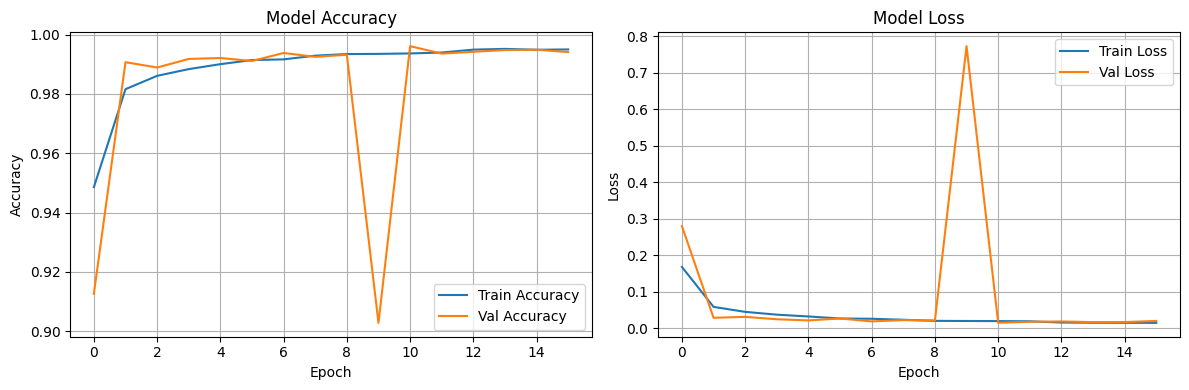

Training history saved → training_history.png


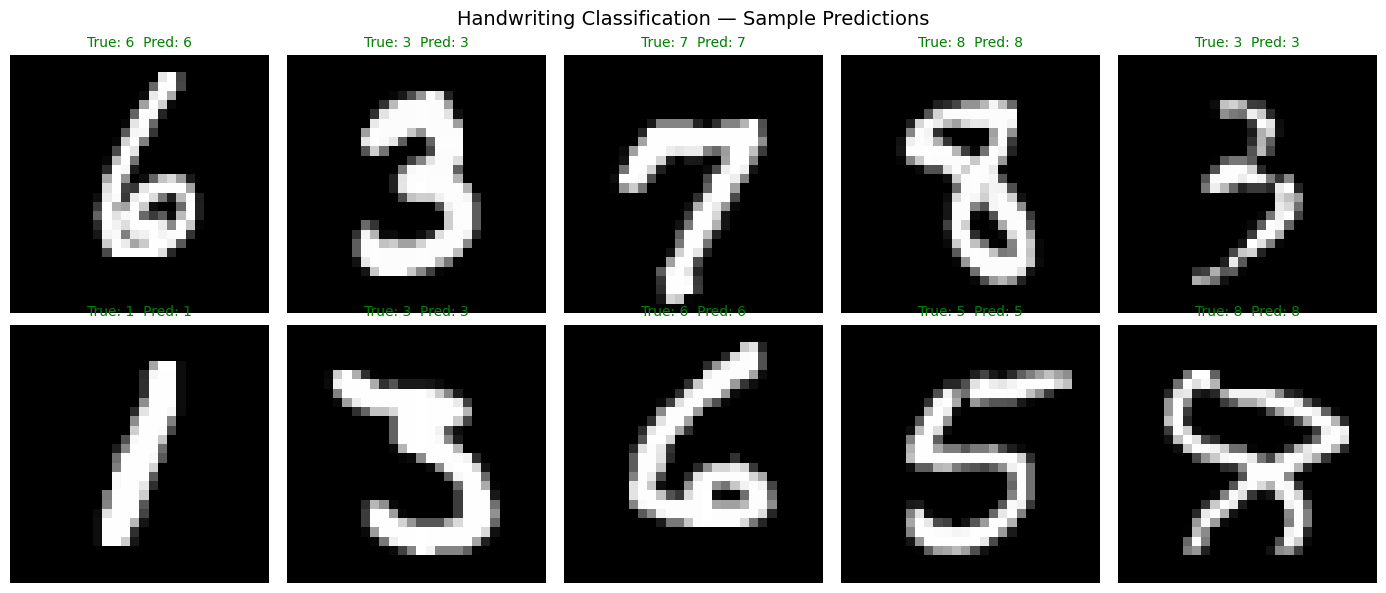

Sample predictions saved → sample_predictions.png

Done! Trained model saved → best_mnist_model.keras


In [10]:
if __name__ == "__main__":
    print("\n=== MNIST Handwriting Classification ===\n")

    # Step 1 – Data
    X_train, y_train, X_test, y_test, y_train_ohe, y_test_ohe = load_data()

    # Step 2 – Model
    model = build_model()
    model.summary()

    # Step 3 – Train
    print("\n[Training ...]\n")
    history = train_model(model, X_train, y_train_ohe, X_test, y_test_ohe)

    # Step 4 – Evaluate
    evaluate_model(model, X_test, y_test_ohe)

    # Step 5 – Plots
    plot_history(history)

    # Step 6 – Demo predictions
    predict_samples(model, X_test, y_test)

    print("\nDone! Trained model saved → best_mnist_model.keras")

